# Model Comparison

Baseline vs. supervised models on the held-out test set — confusion matrices, metrics, and top zip codes from the best model.

In [43]:
!pip3 install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_10_13_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_10_13_x86_64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_10_13_x86_64.whl (293 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 27.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [44]:
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from baseline_scoring import (
    BASELINE_WEIGHTS,
    TOP_QUANTILE,
    baseline_score,
    baseline_used_columns,
    fit_zscore,
    zscore_matrix,
)
from supervised_models import (
    binary_metrics_dict,
    make_logistic_regression,
    make_random_forest,
    ml_feature_columns,
)

TRAIN = os.path.join("data", "output", "train.csv")
TEST = os.path.join("data", "output", "test.csv")

In [ ]:
train = pd.read_csv(TRAIN, low_memory=False)
test = pd.read_csv(TEST, low_memory=False)
y_train = train["label"].to_numpy()
y_test = test["label"].to_numpy()

def show_model(name: str, y_true, y_pred, y_proba=None):
    m = binary_metrics_dict(y_true, y_pred, y_proba)
    print("Accuracy:" + str(m['accuracy']))
    print("Precision:" + str(m['precision']))
    print("Recall:" + str(m['recall']))
    print("F1:" + str(m['f1']))
    if m.get("roc_auc") is not None:
        print("ROC-AUC:" + str(m['roc_auc']))

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Low growth", "High growth"],
        cmap="Blues", ax=ax,
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

Baseline
  Accuracy:  0.5592
  Precision: 0.1606
  Recall:    0.1485
  F1:        0.1543
  ROC-AUC:   0.4316


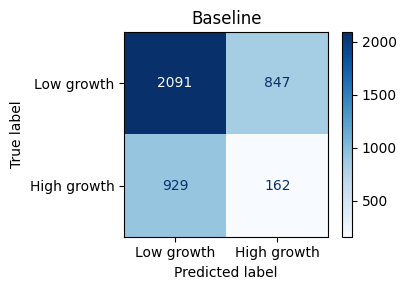

In [50]:
used = baseline_used_columns(train)
mu, sigma = fit_zscore(train, used)
z_tr = zscore_matrix(train, used, mu, sigma)
z_te = zscore_matrix(test, used, mu, sigma)

s_tr = baseline_score(z_tr, used, None)
s_te = baseline_score(z_te, used, None)
thresh = float(np.quantile(s_tr, TOP_QUANTILE))
pred_baseline = (s_te >= thresh).astype(int)

s_min, s_max = float(s_tr.min()), float(s_tr.max())
baseline_proba = np.clip((s_te - s_min) / (s_max - s_min), 0, 1)
print("Baseline")
show_model("Baseline", y_test, pred_baseline, baseline_proba)

Logistic Regression
  Accuracy:  0.7600
  Precision: 0.5384
  Recall:    0.7974
  F1:        0.6428
  ROC-AUC:   0.8470


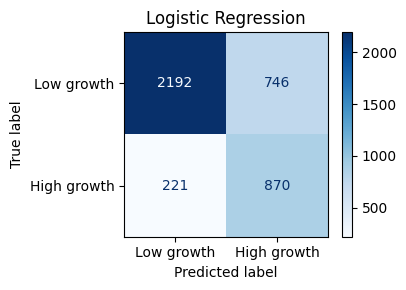

In [51]:
feat_cols = ml_feature_columns(train)
X_train = train[feat_cols].to_numpy(dtype=np.float64)
X_test = test[feat_cols].to_numpy(dtype=np.float64)

lr = make_logistic_regression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
print("Logistic Regression")
show_model("Logistic Regression", y_test, lr_pred, lr_proba)

Random Forest
  Accuracy:  0.7955
  Precision: 0.5968
  Recall:    0.7544
  F1:        0.6664
  ROC-AUC:   0.8715


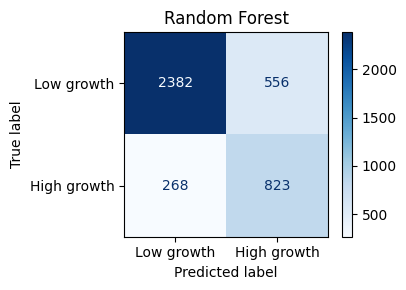

In [52]:
rf = make_random_forest()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("Random Forest")
show_model("Random Forest", y_test, rf_pred, rf_proba)

## Top Zip Codes (Random Forest)

In [53]:
top = test[["RegionName", "City", "State", "Metro", "growth_forecast_1yr"]].copy()
top["rf_proba"] = rf_proba
top = (
    top.sort_values("rf_proba", ascending=False)
    .head(25)
    .reset_index(drop=True)
)
top.index = top.index + 1
top.rename(columns={
    "RegionName": "Zip",
    "growth_forecast_1yr": "Forecast Growth (1yr)",
    "rf_proba": "RF Confidence",
}, inplace=True)
top["RF Confidence"] = top["RF Confidence"].round(4)
top["Forecast Growth (1yr)"] = top["Forecast Growth (1yr)"].round(4)
top

,Zip,City,State,Metro,Forecast Growth (1yr),RF Confidence
1,49829,Escanaba,MI,"Escanaba, MI",3.0,0.9616
2,13212,North Syracuse,NY,"Syracuse, NY",4.0,0.9582
3,13080,Jordan,NY,"Syracuse, NY",3.9,0.9579
4,27239,Denton,NC,"Winston-Salem, NC",1.7,0.9511
5,54124,Gillett,WI,"Green Bay, WI",4.4,0.9494
6,13088,Liverpool,NY,"Syracuse, NY",4.0,0.9493
7,44864,Perrysville,OH,"Ashland, OH",2.7,0.9490
8,13421,Oneida,NY,"Syracuse, NY",3.5,0.9489
9,54304,Green Bay,WI,"Green Bay, WI",4.0,0.9468
10,61111,Loves Park,IL,"Rockford, IL",4.2,0.9467
